In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/projet3/"

train = pd.read_csv(path + "train.csv")
val   = pd.read_csv(path + "validation.csv")
test  = pd.read_csv(path + "test.csv")

print("Train:", train.shape)
print("Val:  ", val.shape)
print("Test: ", test.shape)

Train: (1200000, 9)
Val:   (30000, 9)
Test:  (30000, 9)


In [ ]:
!pip install pandas numpy matplotlib seaborn plotly
!pip install transformers datasets scikit-learn torch
!pip install bertopic sentence-transformers
!pip install langdetect spacy emoji wordcloud
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 55.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=965b44adebe728e66d334f789a1058548c2d692de9e7320a4f43cbd539d050ff
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 122.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install emoji -q

import re, emoji, pandas as pd

# Keep only English + sample 15,000
df = train[train['language'] == 'en'].sample(15000, random_state=42).copy()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = emoji.demojize(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['review_body'].apply(clean_text)
df = df[df['clean_text'].str.len() > 20]

def make_label(stars):
    if stars >= 4: return 2
    elif stars == 3: return 1
    else: return 0

df['label'] = df['stars'].apply(make_label)

print("✅ Clean dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())
df[['clean_text', 'stars', 'label']].head(3)

✅ Clean dataset shape: (14929, 11)

Label distribution:
label
2    5986
0    5937
1    3006
Name: count, dtype: int64


,clean_text,stars,label
319737,Not strong enough to run a small 120v vacuum c...,3,1
272272,"The leg openings are a little small, but other...",2,0
358154,Really cute mug. I would have given 5 stars if...,4,2


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score
import numpy as np

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Prepare data
data = df[['clean_text', 'label']].rename(columns={'clean_text': 'text'})
dataset = Dataset.from_pandas(data.reset_index(drop=True))
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# Tokenize
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding=True, max_length=128)

dataset = dataset.map(tokenize, batched=True)

# Model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

# F1 metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1 = f1_score(labels, preds, average='macro')
    return {"f1_macro": f1}

# Training config (fixed)
args = TrainingArguments(
    output_dir="/content/drive/MyDrive/projet3/sentiment_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",        # ← fixed name
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    fp16=True,
)

# Train
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2241, training_loss=0.47164212864778343, metrics={'train_runtime': 286.3818, 'train_samples_per_second': 125.109, 'train_steps_per_second': 7.825, 'total_flos': 1186564766932224.0, 'train_loss': 0.47164212864778343, 'epoch': 3.0})

In [ ]:
# Save model and tokenizer to Drive
model.save_pretrained("/content/drive/MyDrive/projet3/sentiment_model")
tokenizer.save_pretrained("/content/drive/MyDrive/projet3/sentiment_model")
print("✅ Model saved to Drive!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to Drive!


In [ ]:
# Use more data this time - 40,000 reviews
df2 = train[train['language'] == 'en'].sample(40000, random_state=42).copy()
df2['clean_text'] = df2['review_body'].apply(clean_text)
df2 = df2[df2['clean_text'].str.len() > 20]
df2['label'] = df2['stars'].apply(make_label)

data2 = df2[['clean_text', 'label']].rename(columns={'clean_text': 'text'})
dataset2 = Dataset.from_pandas(data2.reset_index(drop=True))
dataset2 = dataset2.train_test_split(test_size=0.2, seed=42)
dataset2 = dataset2.map(tokenize, batched=True)

# Fresh model
model2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

args2 = TrainingArguments(
    output_dir="/content/drive/MyDrive/projet3/sentiment_model_v2",
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
)

trainer2 = Trainer(
    model=model2,
    args=args2,
    train_dataset=dataset2['train'],
    eval_dataset=dataset2['test'],
    compute_metrics=compute_metrics,
)

trainer2.train()

Map:   0%|          | 0/31840 [00:00<?, ? examples/s]

Map:   0%|          | 0/7961 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.589186,0.597013,0.677468
2,0.525540,0.578339,0.693888
3,0.425609,0.622539,0.692945
4,0.350694,0.669974,0.695481
5,0.283564,0.724480,0.697288


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4975, training_loss=0.4553468219239508, metrics={'train_runtime': 763.389, 'train_samples_per_second': 208.544, 'train_steps_per_second': 6.517, 'total_flos': 5272296488755200.0, 'train_loss': 0.4553468219239508, 'epoch': 5.0})

In [ ]:
from sklearn.utils import resample

# Balance the classes equally
pos = df2[df2['label'] == 2]
neg = df2[df2['label'] == 0]
neu = df2[df2['label'] == 1]

# Upsample neutral to match others
neu_upsampled = resample(neu, replace=True, n_samples=len(pos), random_state=42)

df3 = pd.concat([pos, neg, neu_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print("New label distribution:")
print(df3['label'].value_counts())

# Prepare dataset
data3 = df3[['clean_text', 'label']].rename(columns={'clean_text': 'text'})
dataset3 = Dataset.from_pandas(data3)
dataset3 = dataset3.train_test_split(test_size=0.2, seed=42)
dataset3 = dataset3.map(tokenize, batched=True)

# Fresh model
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
model3 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

args3 = TrainingArguments(
    output_dir="/content/drive/MyDrive/projet3/sentiment_model_v3",
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
)

trainer3 = Trainer(
    model=model3,
    args=args3,
    train_dataset=dataset3['train'],
    eval_dataset=dataset3['test'],
    compute_metrics=compute_metrics,
)

trainer3.train()

New label distribution:
label
2    15980
1    15980
0    15925
Name: count, dtype: int64


Map:   0%|          | 0/38308 [00:00<?, ? examples/s]

Map:   0%|          | 0/9577 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5990, training_loss=0.3618435862864397, metrics={'train_runtime': 846.9102, 'train_samples_per_second': 226.163, 'train_steps_per_second': 7.073, 'total_flos': 6343314506634240.0, 'train_loss': 0.3618435862864397, 'epoch': 5.0})

In [ ]:
from sklearn.utils import resample

# Use more data - 60,000 reviews
df4 = train[train['language'] == 'en'].sample(60000, random_state=99).copy()
df4['clean_text'] = df4['review_body'].apply(clean_text)
df4 = df4[df4['clean_text'].str.len() > 20]
df4['label'] = df4['stars'].apply(make_label)

# Balance classes
pos4 = df4[df4['label'] == 2]
neg4 = df4[df4['label'] == 0]
neu4 = df4[df4['label'] == 1]
n = min(len(pos4), len(neg4))
neu4_up = resample(neu4, replace=True, n_samples=n, random_state=42)
df4 = pd.concat([pos4, neg4, neu4_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Label distribution:")
print(df4['label'].value_counts())

# Prepare dataset
data4 = df4[['clean_text', 'label']].rename(columns={'clean_text': 'text'})
dataset4 = Dataset.from_pandas(data4)
dataset4 = dataset4.train_test_split(test_size=0.2, seed=42)
dataset4 = dataset4.map(tokenize, batched=True)

# Fresh model
model4 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

args4 = TrainingArguments(
    output_dir="/content/drive/MyDrive/projet3/sentiment_model_v4",
    num_train_epochs=7,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=200,
    fp16=True,
)

trainer4 = Trainer(
    model=model4,
    args=args4,
    train_dataset=dataset4['train'],
    eval_dataset=dataset4['test'],
    compute_metrics=compute_metrics,
)

trainer4.train()

Label distribution:
label
2    23836
0    23821
1    23821
Name: count, dtype: int64


Map:   0%|          | 0/57182 [00:00<?, ? examples/s]

Map:   0%|          | 0/14296 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=12509, training_loss=0.31905646609672966, metrics={'train_runtime': 1704.6373, 'train_samples_per_second': 234.815, 'train_steps_per_second': 7.338, 'total_flos': 1.3256050281030144e+16, 'train_loss': 0.31905646609672966, 'epoch': 7.0})

In [ ]:
# 2-class approach: only positive and negative (drop neutral/3-star)
df5 = train[train['language'] == 'en'].copy()
df5['clean_text'] = df5['review_body'].apply(clean_text)
df5 = df5[df5['clean_text'].str.len() > 20]

# Keep only 1,2,4,5 stars — drop 3 stars (ambiguous)
df5 = df5[df5['stars'] != 3]

# Binary label
df5['label'] = df5['stars'].apply(lambda s: 1 if s >= 4 else 0)

# Balance and sample
pos5 = df5[df5['label'] == 1].sample(30000, random_state=42)
neg5 = df5[df5['label'] == 0].sample(30000, random_state=42)
df5 = pd.concat([pos5, neg5]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Label distribution:")
print(df5['label'].value_counts())

# Prepare
data5 = df5[['clean_text', 'label']].rename(columns={'clean_text': 'text'})
dataset5 = Dataset.from_pandas(data5)
dataset5 = dataset5.train_test_split(test_size=0.2, seed=42)
dataset5 = dataset5.map(tokenize, batched=True)

# Fresh model - 2 labels this time
model5 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

args5 = TrainingArguments(
    output_dir="/content/drive/MyDrive/projet3/sentiment_model_v5",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
)

trainer5 = Trainer(
    model=model5,
    args=args5,
    train_dataset=dataset5['train'],
    eval_dataset=dataset5['test'],
    compute_metrics=compute_metrics,
)

trainer5.train()

Label distribution:
label
1    30000
0    30000
Name: count, dtype: int64


Map:   0%|          | 0/48000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6000, training_loss=0.1397713796297709, metrics={'train_runtime': 849.9099, 'train_samples_per_second': 225.906, 'train_steps_per_second': 7.06, 'total_flos': 6358435135488000.0, 'train_loss': 0.1397713796297709, 'epoch': 4.0})

In [ ]:
# Save final model to Drive
model5.save_pretrained("/content/drive/MyDrive/projet3/sentiment_final")
tokenizer.save_pretrained("/content/drive/MyDrive/projet3/sentiment_final")
print("✅ Final model saved!")

# Quick test - try it on some examples
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/projet3/sentiment_final",
    tokenizer="/content/drive/MyDrive/projet3/sentiment_final"
)

examples = [
    "This product is absolutely amazing, I love it!",
    "Terrible quality, broke after one day. Total waste of money.",
    "Fast delivery and exactly as described.",
    "Very disappointed, not worth the price at all."
]

for text in examples:
    result = classifier(text)[0]
    label = "POSITIVE ✅" if result['label'] == 'LABEL_1' else "NEGATIVE ❌"
    print(f"{label} ({result['score']:.2f}) → {text[:50]}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Final model saved!


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE ✅ (1.00) → This product is absolutely amazing, I love it!
NEGATIVE ❌ (1.00) → Terrible quality, broke after one day. Total waste
POSITIVE ✅ (1.00) → Fast delivery and exactly as described.
NEGATIVE ❌ (1.00) → Very disappointed, not worth the price at all.


In [ ]:
!pip install bertopic -q

from bertopic import BERTopic
import plotly.express as px
import pandas as pd

# Use a sample of reviews for topic modeling
df_topics = train[train['language'] == 'en'].sample(10000, random_state=42).copy()
df_topics['clean_text'] = df_topics['review_body'].apply(clean_text)
df_topics = df_topics[df_topics['clean_text'].str.len() > 20].reset_index(drop=True)

print(f"✅ Reviews for topic modeling: {len(df_topics)}")

# Train BERTopic
topic_model = BERTopic(
    language="english",
    nr_topics=20,        # find 15-20 topics
    verbose=True,
    calculate_probabilities=True
)

topics, probs = topic_model.fit_transform(df_topics['clean_text'].tolist())
df_topics['topic'] = topics

# Show topics found
topic_info = topic_model.get_topic_info()
print("\n📊 Topics discovered:")
print(topic_info[['Topic', 'Count', 'Name']].head(20))

2026-05-04 11:13:38,380 - BERTopic - Embedding - Transforming documents to embeddings.


✅ Reviews for topic modeling: 9951


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

2026-05-04 11:13:49,669 - BERTopic - Embedding - Completed ✓
2026-05-04 11:13:49,670 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 11:14:31,208 - BERTopic - Dimensionality - Completed ✓
2026-05-04 11:14:31,209 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 11:14:41,204 - BERTopic - Cluster - Completed ✓
2026-05-04 11:14:41,205 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-04 11:14:41,605 - BERTopic - Representation - Completed ✓
2026-05-04 11:14:41,606 - BERTopic - Topic reduction - Reducing number of topics
2026-05-04 11:14:41,634 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 11:14:41,946 - BERTopic - Representation - Completed ✓
2026-05-04 11:14:41,951 - BERTopic - Topic reduction - Reduced number of topics from 160 to 20



📊 Topics discovered:
    Topic  Count                            Name
0      -1   3328                -1_the_it_to_and
1       0   1476                 0_the_and_it_to
2       1    787                 1_the_to_it_and
3       2    720                2_it_for_and_the
4       3    654            3_book_the_story_and
5       4    461                 4_the_it_and_to
6       5    418                 5_it_my_hair_to
7       6    379        6_was_received_the_never
8       7    343                 7_to_the_it_and
9       8    265          8_lights_light_the_and
10      9    258               9_the_it_water_to
11     10    247        10_case_screen_phone_the
12     11    201             11_the_ink_to_cards
13     12    148             12_dog_collar_my_he
14     13    116  13_smaller_than_expected_small
15     14     58     14_the_umbrella_tent_window
16     15     39        15_fan_thermostat_it_air
17     16     25        16_rug_rugs_the_flooring
18     17     15        17_mirror_the_it_bracke

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency
import numpy as np

# Add star ratings to topics df
df_topics['stars'] = df_topics['stars'].astype(int)

# Better topic names (manual mapping based on what we see)
topic_names = {
    -1: "Other",
     0: "General",
     1: "General Quality",
     2: "General Use",
     3: "Books & Stories",
     4: "Delivery Issues",
     5: "General Feel",
     6: "General Review",
     7: "Hair Products",
     8: "Lighting",
     9: "Phone Cases",
    10: "Installation & Fit",
    11: "Pet Products",
    12: "Ink & Printers",
    13: "Water & Hose",
    14: "Clocks & Planners",
    15: "Hooks & Hanging",
    16: "Balls & Pumps",
    17: "Mirrors",
    18: "Gems & Stones"
}

df_topics['topic_name'] = df_topics['topic'].map(topic_names)

# ── 1. Average star rating per topic ──────────────────────────────
avg_stars = df_topics.groupby('topic_name')['stars'].mean().sort_values()
avg_stars = avg_stars[avg_stars.index != "Other"]  # remove noise topic

fig1 = px.bar(
    avg_stars.reset_index(),
    x='stars', y='topic_name',
    orientation='h',
    color='stars',
    color_continuous_scale='RdYlGn',
    title='⭐ Average Star Rating per Topic',
    labels={'stars': 'Average Stars', 'topic_name': 'Topic'}
)
fig1.add_vline(x=3.0, line_dash="dash", line_color="red",
               annotation_text="⚠️ Needs improvement (< 3.0)")
fig1.show()

# ── 2. Heatmap: Topic × Star Rating ───────────────────────────────
heat = df_topics[df_topics['topic'] != -1].groupby(
    ['topic_name', 'stars']
).size().reset_index(name='count')

heat_pivot = heat.pivot(index='topic_name', columns='stars', values='count').fillna(0)

fig2 = px.imshow(
    heat_pivot,
    color_continuous_scale='Blues',
    title='🔥 Heatmap: Topic × Star Rating',
    labels=dict(x="Star Rating", y="Topic", color="Review Count"),
    aspect="auto"
)
fig2.show()

# ── 3. Chi-square test ─────────────────────────────────────────────
print("\n📊 Chi-square test (Topic vs Star Rating):")
contingency = heat_pivot.values
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.6f}, degrees of freedom = {dof}")
if p < 0.05:
    print("✅ Significant association between topics and star ratings (p < 0.05)")

# ── 4. Low scoring topics (needs improvement) ─────────────────────
print("\n⚠️  Topics needing improvement (avg stars < 3.5):")
low = avg_stars[avg_stars < 3.5]
for topic, score in low.items():
    print(f"  → {topic}: {score:.2f} ⭐")


📊 Chi-square test (Topic vs Star Rating):
Chi2 = 622.89, p-value = 0.000000, degrees of freedom = 72
✅ Significant association between topics and star ratings (p < 0.05)

⚠️  Topics needing improvement (avg stars < 3.5):
  → General Review: 2.23 ⭐
  → Hooks & Hanging: 2.44 ⭐
  → Mirrors: 2.73 ⭐
  → General Quality: 2.76 ⭐
  → Installation & Fit: 2.85 ⭐
  → Water & Hose: 2.87 ⭐
  → Phone Cases: 2.90 ⭐
  → Clocks & Planners: 2.98 ⭐
  → Pet Products: 3.00 ⭐
  → Lighting: 3.01 ⭐
  → Delivery Issues: 3.02 ⭐
  → Ink & Printers: 3.05 ⭐
  → General: 3.13 ⭐
  → Hair Products: 3.19 ⭐
  → General Feel: 3.22 ⭐
  → Balls & Pumps: 3.24 ⭐
  → Gems & Stones: 3.31 ⭐
  → Books & Stories: 3.48 ⭐


In [ ]:
# Save the topic model and data to Drive
import os
os.makedirs("/content/drive/MyDrive/projet3/topic_model", exist_ok=True)

topic_model.save("/content/drive/MyDrive/projet3/topic_model/bertopic_model")
df_topics.to_csv("/content/drive/MyDrive/projet3/df_topics.csv", index=False)
df5.to_csv("/content/drive/MyDrive/projet3/df_sentiment.csv", index=False)

print("✅ All data saved to Drive!")
print("Files saved:")
print("  → sentiment_final/   (DistilBERT model)")
print("  → topic_model/       (BERTopic model)")
print("  → df_topics.csv      (reviews with topics)")
print("  → df_sentiment.csv   (reviews with sentiment labels)")

2026-05-04 11:14:44,559 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ All data saved to Drive!
Files saved:
  → sentiment_final/   (DistilBERT model)
  → topic_model/       (BERTopic model)
  → df_topics.csv      (reviews with topics)
  → df_sentiment.csv   (reviews with sentiment labels)


In [ ]:
%%writefile /content/drive/MyDrive/projet3/app.py

import streamlit as st
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

st.set_page_config(page_title="E-commerce Opinion Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv("/content/drive/MyDrive/projet3/df_topics.csv")
    return df

df = load_data()

# ── Sidebar filters ──────────────────────────────────────────────
st.sidebar.title("🔍 Filters")
stars_filter = st.sidebar.multiselect(
    "Star Rating", options=[1,2,3,4,5], default=[1,2,3,4,5]
)
topics_filter = st.sidebar.multiselect(
    "Topic", options=sorted(df['topic_name'].unique()),
    default=sorted(df['topic_name'].unique())
)

filtered = df[
    (df['stars'].isin(stars_filter)) &
    (df['topic_name'].isin(topics_filter))
]

# ── Header ───────────────────────────────────────────────────────
st.title("🛒 E-commerce Opinion Analysis Dashboard")
st.markdown(f"Showing **{len(filtered):,}** reviews")

# ── Row 1: KPIs ──────────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Reviews", f"{len(filtered):,}")
col2.metric("Avg Star Rating", f"{filtered['stars'].mean():.2f} ⭐")
col3.metric("Topics Found", filtered['topic_name'].nunique())
col4.metric("Categories", filtered['product_category'].nunique()
            if 'product_category' in filtered.columns else "N/A")

st.divider()

# ── Row 2: Rating histogram + bar chart ──────────────────────────
col1, col2 = st.columns(2)

with col1:
    st.subheader("⭐ Rating Distribution")
    fig1 = px.histogram(
        filtered, x='stars',
        color_discrete_sequence=['#636EFA'],
        labels={'stars': 'Star Rating'}
    )
    st.plotly_chart(fig1, use_container_width=True)

with col2:
    st.subheader("📊 Average Rating per Topic")
    avg = filtered.groupby('topic_name')['stars'].mean().sort_values().reset_index()
    fig2 = px.bar(
        avg, x='stars', y='topic_name', orientation='h',
        color='stars',
        color_continuous_scale='RdYlGn',
        labels={'stars': 'Avg Stars', 'topic_name': 'Topic'}
    )
    fig2.add_vline(x=3.0, line_dash="dash", line_color="red")
    st.plotly_chart(fig2, use_container_width=True)

st.divider()

# ── Row 3: Heatmap ───────────────────────────────────────────────
st.subheader("🔥 Heatmap: Topic × Star Rating")
heat = filtered.groupby(['topic_name','stars']).size().reset_index(name='count')
heat_pivot = heat.pivot(index='topic_name', columns='stars', values='count').fillna(0)
fig3 = px.imshow(
    heat_pivot,
    color_continuous_scale='Blues',
    labels=dict(x="Star Rating", y="Topic", color="Reviews"),
    aspect="auto"
)
st.plotly_chart(fig3, use_container_width=True)

st.divider()

# ── Row 4: Word Cloud ────────────────────────────────────────────
st.subheader("☁️ Word Cloud")
text = " ".join(filtered['clean_text'].dropna().sample(
    min(2000, len(filtered)), random_state=42).tolist())
wc = WordCloud(width=1200, height=400,
               background_color='white', colormap='Blues').generate(text)
fig4, ax = plt.subplots(figsize=(12, 4))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
st.pyplot(fig4)

st.divider()

# ── Row 5: Marketing recommendations ─────────────────────────────
st.subheader("📢 Marketing Action Plan")
avg_all = df.groupby('topic_name')['stars'].mean()
low_topics = avg_all[avg_all < 3.0].sort_values()

if len(low_topics) > 0:
    for topic, score in low_topics.items():
        st.error(f"🚨 **{topic}** → avg {score:.2f} ⭐ — Urgent improvement needed!")
else:
    st.success("✅ All topics scoring above 3.0!")

st.caption("Dashboard built with Streamlit · BERTopic · DistilBERT")

In [ ]:
# Réinstaller tout
!pip install streamlit wordcloud plotly -q
!npm install -g localtunnel -q
print("✅ Installé !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴✅ Installé !


In [ ]:
import subprocess, time, os

# Kill old streamlit
subprocess.run(["pkill", "-f", "streamlit"])
time.sleep(2)

os.chdir("/content/drive/MyDrive/projet3/")
proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port=8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(5)
!lt --port 8501

your url is: https://khaki-wings-occur.loca.lt


In [ ]:
!pip install shap -q

import shap
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import pipeline

# Load your saved model
classifier = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/projet3/sentiment_final",
    tokenizer="/content/drive/MyDrive/projet3/sentiment_final",
    return_all_scores=True
)

# Pick 20 sample reviews for SHAP
samples = df5['clean_text'].dropna().sample(20, random_state=42).tolist()

# Build SHAP explainer
explainer = shap.Explainer(classifier)
shap_values = explainer(samples[:5])  # start with 5 for speed

# Plot SHAP for first review
print("Review:", samples[0])
print()
shap.plots.text(shap_values[0])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
PartitionExplainer explainer: 6it [00:10,  5.42s/it]

Review: Noisey tires, kinda annoying and I'm stuck using them for awhile.



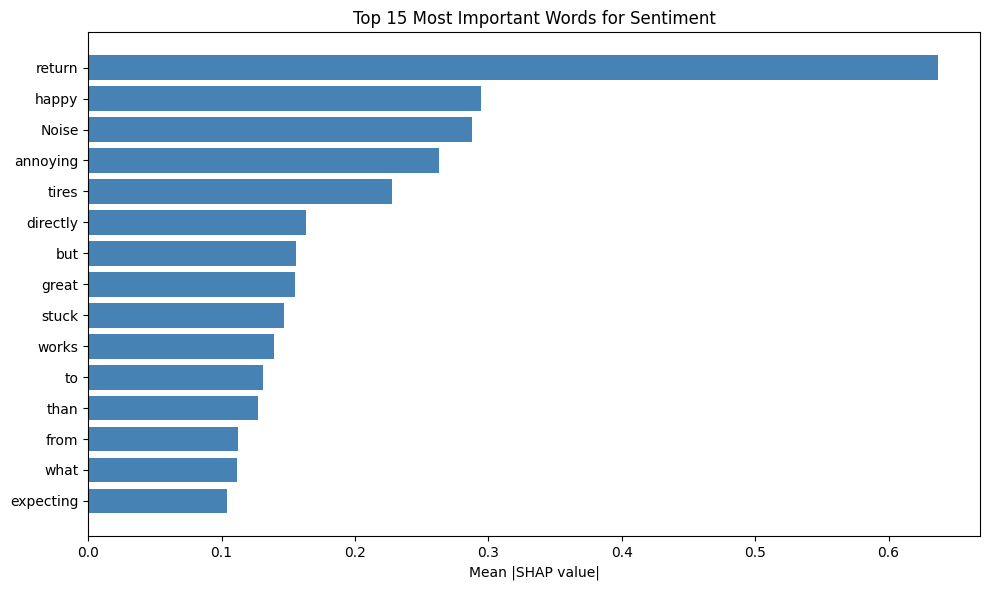

✅ SHAP summary plot saved!


In [ ]:
# Fix summary plot
plt.figure(figsize=(10, 6))

# Get word importance values correctly
words = shap_values.feature_names
values = shap_values[:, :, 0].values  # negative class

# Average absolute SHAP value per word across all samples
import numpy as np
import pandas as pd

# Flatten and get top words
all_words = []
all_vals = []
for i in range(len(shap_values)):
    for j, word in enumerate(shap_values[i].feature_names):
        all_words.append(word)
        all_vals.append(abs(shap_values[i, j, 0].values))

word_importance = pd.DataFrame({'word': all_words, 'importance': all_vals})
word_importance = word_importance.groupby('word')['importance'].mean().sort_values(ascending=False).head(15)

# Plot
plt.barh(word_importance.index[::-1], word_importance.values[::-1], color='steelblue')
plt.xlabel("Mean |SHAP value|")
plt.title("Top 15 Most Important Words for Sentiment")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projet3/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved!")

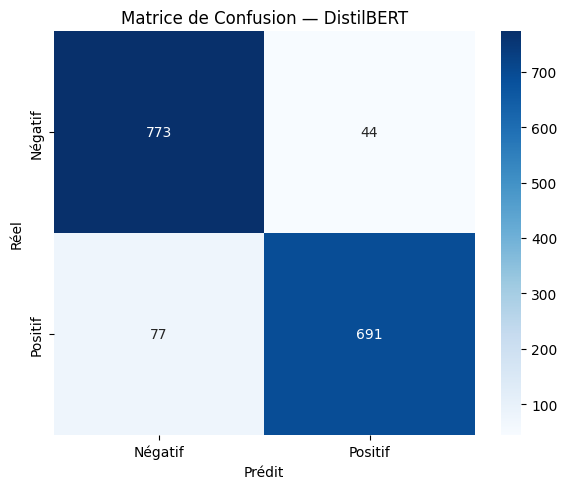


📊 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.91      0.95      0.93       817
     Positif       0.94      0.90      0.92       768

    accuracy                           0.92      1585
   macro avg       0.92      0.92      0.92      1585
weighted avg       0.92      0.92      0.92      1585



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur le test set
test_en = test[test['language'] == 'en'].sample(2000, random_state=42).copy()
test_en['clean_text'] = test_en['review_body'].apply(clean_text)
test_en = test_en[test_en['clean_text'].str.len() > 20]
test_en = test_en[test_en['stars'] != 3]  # binary comme le modèle
test_en['true_label'] = test_en['stars'].apply(lambda s: 1 if s >= 4 else 0)

# Prédire
results = classifier(test_en['clean_text'].tolist(), truncation=True, max_length=128)
test_en['pred_label'] = [1 if r['label'] == 'LABEL_1' else 0 for r in results]

# Matrice de confusion
cm = confusion_matrix(test_en['true_label'], test_en['pred_label'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'], ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de Confusion — DistilBERT')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projet3/confusion_matrix.png", dpi=150)
plt.show()

# Rapport complet
print("\n📊 Rapport de classification :")
print(classification_report(test_en['true_label'], test_en['pred_label'],
                            target_names=['Négatif', 'Positif']))

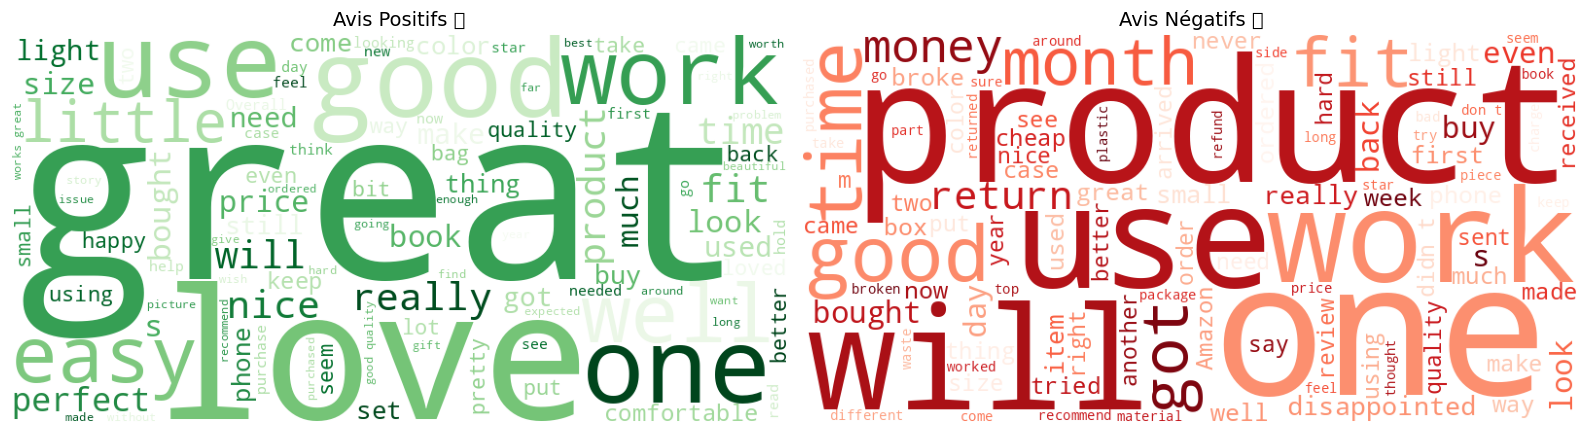

✅ EDA complète !


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Distribution des notes
fig1 = px.histogram(df, x='stars', color='stars',
                    color_discrete_sequence=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60'],
                    title='Distribution des notes (1 à 5 étoiles)',
                    labels={'stars': 'Note', 'count': 'Nombre d\'avis'})
fig1.show()

# 2. Notes moyennes par catégorie (top 10)
cat_avg = df.groupby('product_category')['stars'].mean().sort_values().tail(10).reset_index()
fig2 = px.bar(cat_avg, x='stars', y='product_category', orientation='h',
              color='stars', color_continuous_scale='RdYlGn',
              title='Note moyenne par catégorie (Top 10)',
              labels={'stars': 'Note moyenne', 'product_category': 'Catégorie'})
fig2.add_vline(x=3.0, line_dash="dash", line_color="red")
fig2.show()

# 3. Longueur des avis par sentiment
df['text_length'] = df['clean_text'].apply(len)
fig3 = px.box(df, x='label', y='text_length',
              color='label',
              color_discrete_map={0: '#E74C3C', 1: '#F1C40F', 2: '#27AE60'},
              title='Longueur des avis par sentiment',
              labels={'label': 'Sentiment (0=Négatif, 1=Neutre, 2=Positif)',
                      'text_length': 'Longueur (caractères)'})
fig3.show()

# 4. Word cloud positif vs négatif
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pos_text = " ".join(df[df['label'] == 2]['clean_text'].dropna().sample(2000, random_state=42))
neg_text = " ".join(df[df['label'] == 0]['clean_text'].dropna().sample(2000, random_state=42))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)

axes[0].imshow(wc_pos); axes[0].axis('off'); axes[0].set_title('Avis Positifs ✅', fontsize=14)
axes[1].imshow(wc_neg); axes[1].axis('off'); axes[1].set_title('Avis Négatifs ❌', fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projet3/wordclouds.png", dpi=150)
plt.show()

print("✅ EDA complète !")

In [ ]:
# Évolution des notes dans le temps (par catégorie)
# On simule une date car le dataset n'a pas de colonne date directe
# On utilise l'index comme proxy temporel

df_time = df.copy().reset_index(drop=True)
df_time['batch'] = df_time.index // 500  # groupes de 500 avis

time_trend = df_time.groupby('batch')['stars'].mean().reset_index()

fig4 = px.line(time_trend, x='batch', y='stars',
               title='Évolution de la note moyenne dans le corpus',
               labels={'batch': 'Segment temporel', 'stars': 'Note moyenne'},
               color_discrete_sequence=['#2E5A9C'])
fig4.add_hline(y=3.0, line_dash="dash", line_color="red",
               annotation_text="Seuil critique 3.0")
fig4.show()

# Évolution par thème (top 5 thèmes)
top_themes = df_topics['topic_name'].value_counts().head(5).index.tolist()
df_theme_time = df_topics[df_topics['topic_name'].isin(top_themes)].copy().reset_index(drop=True)
df_theme_time['batch'] = df_theme_time.index // 100

theme_trend = df_theme_time.groupby(['batch', 'topic_name'])['stars'].mean().reset_index()

fig5 = px.line(theme_trend, x='batch', y='stars', color='topic_name',
               title='Évolution des notes par thème',
               labels={'batch': 'Segment', 'stars': 'Note moyenne', 'topic_name': 'Thème'})
fig5.add_hline(y=3.0, line_dash="dash", line_color="red")
fig5.show()

print("✅ Courbes temporelles générées !")

✅ Courbes temporelles générées !
